In [ ]:
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

od.download("https://www.kaggle.com/competitions/stars-classification/overview")

Skipping, found downloaded files in "./stars-classification" (use force=True to force download)


In [ ]:
train_data = pd.read_csv('/content/stars-classification/train_star.csv')
test_data = pd.read_csv('/content/stars-classification/test_star.csv')
sample_submission = pd.read_csv('/content/stars-classification/sample_submition_stars.csv')

print("РАЗМЕРЫ ДАННЫХ")
print(f"Тренировочные данные: {train_data.shape}")
print(f"Тестовые данные: {test_data.shape}")
print(f"Пример submission: {sample_submission.shape}")

РАЗМЕРЫ ДАННЫХ
Тренировочные данные: (20732, 7)
Тестовые данные: (18820, 6)
Пример submission: (18820, 2)


In [ ]:
print("\nСТРУКТУРА ТРЕНИРОВОЧНЫХ ДАННЫХ")
print(train_data.head())
print("\nКОЛОНКИ")
print(train_data.columns.tolist())
print("АНАЛИЗ")

print("\n1. ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:")
print("Train data:")
print(train_data.isnull().sum())
print("\nTest data:")
print(test_data.isnull().sum())



СТРУКТУРА ТРЕНИРОВОЧНЫХ ДАННЫХ
    Vmag    Plx  e_Plx    B-V  SpType       Amag TargetClass
0   9.99   7.92   1.61  0.646  G5/G6V  19.483625       Giant
1  10.86   3.26   2.12  1.840    M1V:  18.426088       Giant
2   8.83   7.57   1.05  0.461     F3V  18.225480       Giant
3   7.72  24.80   0.89  0.613    G3IV  19.692257       Giant
4   8.81   3.17   1.03  0.872   G6III  16.315296       Dwarf

КОЛОНКИ
['Vmag', 'Plx', 'e_Plx', 'B-V', 'SpType', 'Amag', 'TargetClass']
АНАЛИЗ

1. ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ:
Train data:
Vmag           0
Plx            0
e_Plx          0
B-V            0
SpType         0
Amag           0
TargetClass    0
dtype: int64

Test data:
Vmag      0
Plx       0
e_Plx     0
B-V       0
SpType    0
Amag      0
dtype: int64



2. РАСПРЕДЕЛЕНИЕ КЛАССОВ (TargetClass):
TargetClass
Giant    15793
Dwarf     4939
Name: count, dtype: int64

Гиганты (1): 4939 (23.8%)
Карлики (0): 15793 (76.2%)


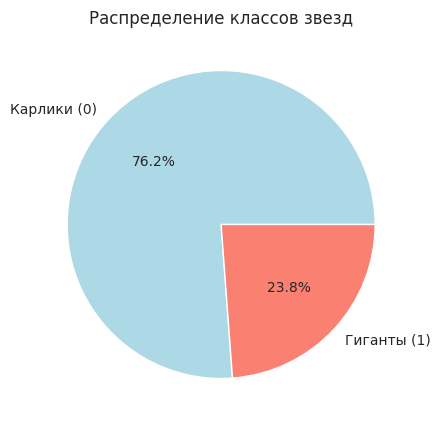

In [ ]:
print("\n2. РАСПРЕДЕЛЕНИЕ КЛАССОВ (TargetClass):")
if 'TargetClass' in train_data.columns:
    class_dist = train_data['TargetClass'].value_counts()
    print(class_dist)
    print(f"\nГиганты (1): {class_dist.get(1, 0)} ({class_dist.get(1, 0)/len(train_data)*100:.1f}%)")
    print(f"Карлики (0): {class_dist.get(0, 0)} ({class_dist.get(0, 0)/len(train_data)*100:.1f}%)")

    plt.figure(figsize=(8, 5))
    plt.pie(class_dist.values, labels=['Карлики (0)', 'Гиганты (1)'],
            autopct='%1.1f%%', colors=['lightblue', 'salmon'])
    plt.title('Распределение классов звезд')
    plt.show()
else:
    print("TargetClass не найден в train_data!")



In [ ]:
print("\n3. СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ:")
print(train_data.describe())

print("\n4. АНАЛИЗ SpType (спектральный тип):")
if 'SpType' in train_data.columns:
    print(f"Уникальных типов: {train_data['SpType'].nunique()}")
    print("Топ-10 частых типов:")
    print(train_data['SpType'].value_counts().head(10))

    print("\nПримеры спектральных типов:")
    print(train_data['SpType'].unique()[:20])



3. СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ:
               Vmag           Plx         e_Plx           B-V          Amag
count  20732.000000  20732.000000  20732.000000  20732.000000  20732.000000
mean       8.045100      8.774717      1.157515      0.584712     16.671187
std        1.299999     15.186434      0.888745      0.457422      2.407249
min       -0.010000    -27.840000      0.420000     -0.400000     -0.350000
25%        7.370000      3.020000      0.820000      0.227000     15.284584
50%        8.280000      5.680000      1.010000      0.526000     16.706049
75%        8.930000     10.170000      1.280000      0.923000     18.282476
max       12.560000    772.330000     40.630000      3.315000     30.449015

4. АНАЛИЗ SpType (спектральный тип):
Уникальных типов: 1681
Топ-10 частых типов:
SpType
F5V      753
K0III    710
F3V      607
A0V      575
F6V      486
F7V      466
K1III    459
B9V      452
G3V      440
F0V      423
Name: count, dtype: int64

Примеры спектральных типов:
['G5/G6

In [ ]:
print("ПРЕДОБРАБОТКА ДАННЫХ")

train = train_data.copy()
test = test_data.copy()

print("1. Преобразование TargetClass")
train['TargetClass_num'] = train['TargetClass'].map({'Dwarf': 0, 'Giant': 1})
print(f"   Распределение: Dwarf(0)={sum(train['TargetClass_num']==0)}, Giant(1)={sum(train['TargetClass_num']==1)}")


ПРЕДОБРАБОТКА ДАННЫХ
1. Преобразование TargetClass
   Распределение: Dwarf(0)=4939, Giant(1)=15793


In [ ]:
print("\n2. Обработка числовых признаков")

train = train[(train['Plx'] > 0) & (train['Plx'] < 100)]
test = test[(test['Plx'] > 0) & (test['Plx'] < 100)]

print(f"   После фильтрации: train {train.shape}, test {test.shape}")


2. Обработка числовых признаков
   После фильтрации: train (20284, 8), test (18079, 6)


In [ ]:
print("\n3. Создание новых признаков")

train['Plx_SNR'] = train['Plx'] / (train['e_Plx'] + 1e-6) #SNR Это отношение сигнал/шум для измерения параллакса.(> 10): Точное измерение, параллакс надежный
test['Plx_SNR'] = test['Plx'] / (test['e_Plx'] + 1e-6)

train['Distance_pc'] = 1 / (train['Plx'] + 1e-6) #Расстояние до звезды в парсеках, вычисленное из параллакса.


test['Distance_pc'] = 1 / (test['Plx'] + 1e-6)

train['log_Distance'] = np.log10(train['Distance_pc'] + 1)
test['log_Distance'] = np.log10(test['Distance_pc'] + 1)

print("   Созданы признаки: Plx_SNR, Distance_pc, log_Distance")


3. Создание новых признаков
   Созданы признаки: Plx_SNR, Distance_pc, log_Distance


In [ ]:
print("\n4. Обработка SpType (упрощенная)")

def extract_simple_features(sp_type):
    if pd.isna(sp_type):
        return 'G', 5, 'V'

    sp_str = str(sp_type).strip()

    for letter in ['O', 'B', 'A', 'F', 'G', 'K', 'M']:
        if letter in sp_str.upper():
            spectral_letter = letter
            break
    else:
        spectral_letter = 'G'

    spectral_number = 5
    for char in sp_str:
        if char.isdigit():
            spectral_number = int(char)
            break

    luminosity_class = 'V'
    roman_patterns = ['VII', 'VI', 'IV', 'III', 'II', 'I', 'V']
    for pattern in roman_patterns:
        if pattern in sp_str:
            luminosity_class = pattern
            break

    return spectral_letter, spectral_number, luminosity_class

train[['Spec_Letter', 'Spec_Number', 'Lum_Class']] = train['SpType'].apply(lambda x: pd.Series(extract_simple_features(x))
)
test[['Spec_Letter', 'Spec_Number', 'Lum_Class']] = test['SpType'].apply(lambda x: pd.Series(extract_simple_features(x))
)

print(f"   Уникальные спектральные буквы: {sorted(train['Spec_Letter'].unique())}")
print(f"   Уникальные классы светимости: {sorted(train['Lum_Class'].unique())[:10]}...")


4. Обработка SpType (упрощенная)
   Уникальные спектральные буквы: ['A', 'B', 'F', 'G', 'K', 'M', 'O']
   Уникальные классы светимости: ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII']...


In [ ]:
train['Temp_est'] = 4600 * (1/(0.92*train['B-V'] + 1.7) + 1/(0.92*train['B-V'] + 0.62))
test['Temp_est'] = 4600 * (1/(0.92*test['B-V'] + 1.7) + 1/(0.92*test['B-V'] + 0.62))

print(f"Новые размеры train: {train.shape}")
print(f"Новые размеры test: {test.shape}")


Новые размеры train: (20284, 15)
Новые размеры test: (18079, 13)


In [ ]:
spectral_order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
train['Spec_Letter_encoded'] = train['Spec_Letter'].map(spectral_order).fillna(4)
test['Spec_Letter_encoded'] = test['Spec_Letter'].map(spectral_order).fillna(4)


def encode_lum_class(lum):
    lum = str(lum).upper()
    if lum == 'V':
        return 0  # карлики
    else:
        return 1

train['Lum_Class_encoded'] = train['Lum_Class'].apply(encode_lum_class)
test['Lum_Class_encoded'] = test['Lum_Class'].apply(encode_lum_class)

print(f"   Распределение кодов светимости: {train['Lum_Class_encoded'].value_counts().to_dict()}")


   Распределение кодов светимости: {0: 11701, 1: 8583}


In [ ]:
print("\n3. Подготовка финальных признаков")

feature_cols = [
    'Plx', 'B-V', 'Amag',
    'Plx_SNR', 'log_Distance',
    'Lum_Class_encoded', 'Temp_est'
]

available_features = [col for col in feature_cols if col in train.columns]
print(f"Используем {len(available_features)} признаков:")
for i, feat in enumerate(available_features, 1):
    print(f"  {i:2d}. {feat}")


X = train[available_features]
y = train['TargetClass_num']
X_test = test[available_features]

print(f"\nФинальные размеры:")
print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"X_test: {X_test.shape}")
print(f"Баланс классов: Dwarf(0)={sum(y==0)}, Giant(1)={sum(y==1)}")



3. Подготовка финальных признаков
Используем 7 признаков:
   1. Plx
   2. B-V
   3. Amag
   4. Plx_SNR
   5. log_Distance
   6. Lum_Class_encoded
   7. Temp_est

Финальные размеры:
X: (20284, 7)
y: (20284,)
X_test: (18079, 7)
Баланс классов: Dwarf(0)=4754, Giant(1)=15530


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression(C=1.0,
    max_iter=5000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1  # используем все ядра
)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_scaled, y,
                           scoring='f1', cv=cv, n_jobs=-1)

print(f"F1-score по кросс-валидации: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Все scores: {cv_scores}")

model.fit(X_scaled, y)

F1-score по кросс-валидации: 0.9290 (+/- 0.0032)
Все scores: [0.92609504 0.92959167 0.93088334 0.93360161 0.92473844]


LogisticRegression(class_weight='balanced', max_iter=5000, n_jobs=-1,
                   random_state=42)

In [ ]:
print("\nТоп-10 самых важных признаков:")
feature_importance = pd.DataFrame({
    'feature': available_features,
    'coefficient': abs(model.coef_[0])
})
feature_importance = feature_importance.sort_values('coefficient', ascending=False)
print(feature_importance.head(10))


Топ-10 самых важных признаков:
             feature  coefficient
5  Lum_Class_encoded     4.147127
1                B-V     2.054243
2               Amag     1.330059
6           Temp_est     0.793015
3            Plx_SNR     0.444115
4       log_Distance     0.364706
0                Plx     0.282268


In [ ]:
print("БЕЗ ФИЛЬТРАЦИИ ТЕСТОВЫХ ДАННЫХ")

train = train_data.copy()
test = test_data.copy()

train = train[(train['Plx'] > 0) & (train['Plx'] < 100)]
print(f"Тренировочные после фильтрации: {train.shape[0]} строк")


def fix_anomalies(df):
    df = df.copy()

    df.loc[df['Plx'] < 0, 'Plx'] = df.loc[df['Plx'] < 0, 'Plx'].abs()

    plx_99 = df['Plx'].quantile(0.99)
    df.loc[df['Plx'] > plx_99, 'Plx'] = plx_99

    df.loc[df['e_Plx'] == 0, 'e_Plx'] = 0.01

    return df


test = fix_anomalies(test)

train['TargetClass_num'] = train['TargetClass'].map({'Dwarf': 0, 'Giant': 1})

БЕЗ ФИЛЬТРАЦИИ ТЕСТОВЫХ ДАННЫХ
Тренировочные после фильтрации: 20284 строк


In [ ]:
def quick_preprocess(df):
    df = df.copy()

    df['Plx_SNR'] = df['Plx'] / (df['e_Plx'] + 1e-6)
    df['Distance_pc'] = 1 / (df['Plx'] + 1e-6)
    df['log_Distance'] = np.log10(df['Distance_pc'] + 1)
    df['Temp_est'] = 4600 * (1/(0.92*df['B-V'] + 1.7) + 1/(0.92*df['B-V'] + 0.62))

    def get_spectral_class(sp_type):
        sp_str = str(sp_type).upper()
        for letter in ['O', 'B', 'A', 'F', 'G', 'K', 'M']:
            if letter in sp_str:
                return letter
        return 'G'

    df['Spec_Letter'] = df['SpType'].apply(get_spectral_class)
    spectral_order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
    df['Spec_Letter_encoded'] = df['Spec_Letter'].map(spectral_order).fillna(4)

    def get_lum_class(sp_type):
        sp_str = str(sp_type).upper()
        if 'I' in sp_str and 'V' not in sp_str:  # если есть I но нет V
            return 1  # гигант/сверхгигант
        return 0  # карлик

    df['Lum_Class_encoded'] = df['SpType'].apply(get_lum_class)

    return df

train = quick_preprocess(train)
test = quick_preprocess(test)


In [ ]:
feature_cols = ['Plx', 'B-V', 'Amag',
    'Plx_SNR', 'log_Distance',
    'Lum_Class_encoded', 'Temp_est']

X = train[feature_cols]
y = train['TargetClass_num']
X_test = test[feature_cols]

print(f"\nФинальные размеры:")
print(f"X: {X.shape}, y: {y.shape}")
print(f"X_test: {X_test.shape}")



Финальные размеры:
X: (20284, 7), y: (20284,)
X_test: (18820, 7)


In [ ]:
print("ОБУЧЕНИЕ И ПРЕДСКАЗАНИЯ")

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


model_v1 = LogisticRegression(C=0.5,
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)


from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model_v1, X_scaled, y, scoring='f1', cv=3)
print(f"F1-score (CV): {cv_scores.mean():.4f}")


model_v1.fit(X_scaled, y)


y_pred_v1 = model_v1.predict(X_test_scaled)
y_proba_v1 = model_v1.predict_proba(X_test_scaled)[:, 1]

print(f"\nПредсказано гигантов: {sum(y_pred_v1)} ({sum(y_pred_v1)/len(y_pred_v1)*100:.1f}%)")
print(f"Предсказано карликов: {len(y_pred_v1)-sum(y_pred_v1)} ({100-sum(y_pred_v1)/len(y_pred_v1)*100:.1f}%)")

ОБУЧЕНИЕ И ПРЕДСКАЗАНИЯ
F1-score (CV): 0.9986

Предсказано гигантов: 4073 (21.6%)
Предсказано карликов: 14747 (78.4%)


In [ ]:
submission = pd.DataFrame({
    'index': range(len(y_pred_v1)),
    'TargetClass': y_pred_v1
})

submission.to_csv('submission_stars.csv', index=False)
